In [1]:
import pandas as pd
import csv

df = pd.read_csv("pilot5.csv", delimiter = ";")
df.head()

,id,text,timestamp_tamara,flagged_tamara,comment_tamara,tag_tamara,timestamp_anze,flagged_anze,comment_anze,tag_anze,rev_tamara,rev_anze,final_tag
0,301,Vsakršno drugačno ravnanje bi po našem preprič...,2023/03/10 14:29:02,NaN,"Opinion known and stated, very negative.",Negative,2023/03/10 14:26:38,NaN,NaN,Negative,NaN,NaN,NaN
1,302,"Eno od zavajanj, ki so v navedbi priporočil SD...",2023/03/10 14:29:54,True,sarcasm,Negative,2023/03/10 14:28:34,NaN,"No direct opinion, but on negativ side because...",N_Neutral,NaN,NaN,NaN
2,303,"In nadalje pravi, da slovenski sodniki poleg p...",2023/03/10 14:30:22,NaN,"lacks opiniom,nothing negative",P_Neutral,2023/03/10 14:29:58,NaN,Statment in my opinion is negativ.,Negative,NaN,NaN,NaN
3,304,Službena pot oziroma koridorji oziroma neka po...,2023/03/10 14:30:44,NaN,"Nothing negative, lacks opinion",P_Neutral,2023/03/10 14:30:42,NaN,"Stament, nut no direct opinion",P_Neutral,NaN,NaN,NaN
4,305,"Prosim, če preberete magnetogram in boste ugot...",2023/03/10 14:31:34,NaN,"Opinion clear, negative connotation, but the s...",N_Neutral,2023/03/10 14:32:07,NaN,"Just a statement, but the first part seems lik...",N_Neutral,NaN,NaN,NaN


In [2]:
from sklearn.metrics import cohen_kappa_score
annotator1 = df['tag_tamara']
annotator2 = df['tag_anze']
cohen_kappa_score(annotator1, annotator2) 

0.3061115559113957

In [3]:
values_tamara = annotator1.value_counts()
values_tamara

Negative      32
P_Neutral     24
N_Neutral     21
Positive      15
M_Negative     6
M_Positive     2
Name: tag_tamara, dtype: int64

In [4]:
values_anze = annotator2.value_counts()
values_anze

Negative     41
P_Neutral    23
Positive     19
N_Neutral    17
Name: tag_anze, dtype: int64

<AxesSubplot:>

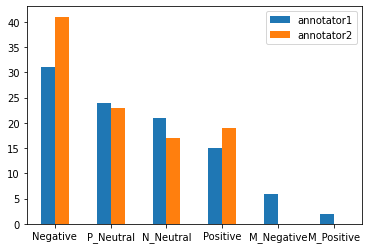

In [5]:
tamara = [31, 24, 21, 15, 6, 2]
anze = [41, 23, 17, 19, 0, 0]
index = ['Negative', 'P_Neutral', 'N_Neutral', 'Positive', 'M_Negative', 'M_Positive']

df3 = pd.DataFrame({'annotator1': tamara, 'annotator2':anze}, index = index)
df3.plot.bar(rot=0)

In [6]:
df.loc[(df['tag_tamara'] == 'Negative') | (df['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df.loc[(df['tag_tamara'] == 'Positive') | (df['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df.loc[(df['tag_tamara'] == 'P_Neutral') | (df['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

In [7]:
df.loc[(df['tag_anze'] == 'Negative') | (df['tag_anze'] == 'M_Negative'), 'sent_anze'] = 'Negative'
df.loc[(df['tag_anze'] == 'Positive') | (df['tag_anze'] == 'M_Positive'), 'sent_anze'] = 'Positive'
df.loc[(df['tag_anze'] == 'P_Neutral') | (df['tag_anze'] == 'N_Neutral'), 'sent_anze'] = 'Neutral'

In [8]:
df1 = df.filter(['id', 'text', 'tag_tamara', 'tag_anze', 'sent_tamara', 'sent_anze'], axis = 1)
#df1 = df.filter(['tag_tamara', 'tag_anze'], axis = 1)

In [9]:
annotator1 = df1['sent_tamara']
annotator2 = df1['sent_anze']
cohen_kappa_score(annotator1, annotator2)

0.3353378699161259

In [10]:
annotator1.value_counts()

Neutral     45
Negative    38
Positive    17
Name: sent_tamara, dtype: int64

In [11]:
annotator2.value_counts()

Negative    41
Neutral     40
Positive    19
Name: sent_anze, dtype: int64

<AxesSubplot:>

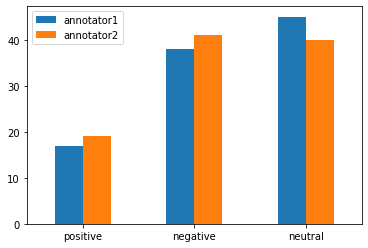

In [12]:
tamara = [17, 38, 45]
anze = [19, 41, 40]
index = ['positive', 'negative', 'neutral']

df3 = pd.DataFrame({'annotator1': tamara, 'annotator2':anze}, index = index)
df3.plot.bar(rot=0)